<a href="https://colab.research.google.com/github/Jee8825/jeeva-codebooster-2026/blob/main/Day_2/mini_project_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Student Performance.csv')
print(df.columns.to_list())

['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
conn= sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql('student_performance',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM student_performance")
count=cursor.fetchone()[0]
print(f"Number of rows in the table: {count}")

Number of rows in the table: 30


In [ ]:
def run_query(sql_string, description_label):
    print(f"\n--- {description_label} ---")
    query_df = pd.read_sql_query(sql_string, conn)
    display(query_df)
    print(f"Rows returned: {len(query_df)}")

In [ ]:
query7 = """SELECT department,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY department
ORDER BY avg_attendance DESC"""
run_query(query7, "Average Attendance Percentage by Department")


--- Average Attendance Percentage by Department ---


,department,avg_attendance
0,Computer Science,90.692308
1,Mechanical,83.500000
2,Electronics,80.333333
3,Civil,74.600000


Rows returned: 4



--- Top 8 Students by Total Score ---


,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356
5,Swati Kulkarni,354
6,Amit Bose,336
7,Suresh Rao,334


Rows returned: 8


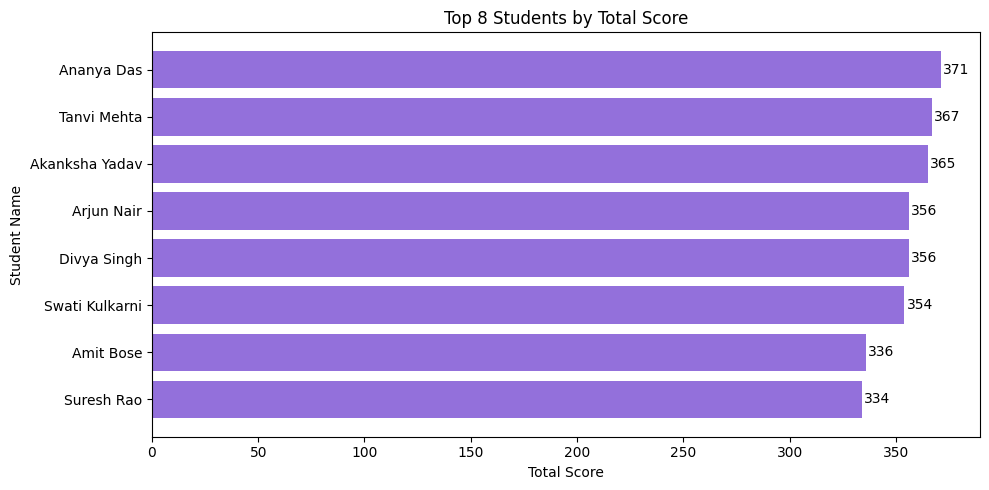


--- Average Attendance by Gender ---


,gender,avg_attendance
0,Female,88.533333
1,Male,80.466667


Rows returned: 2


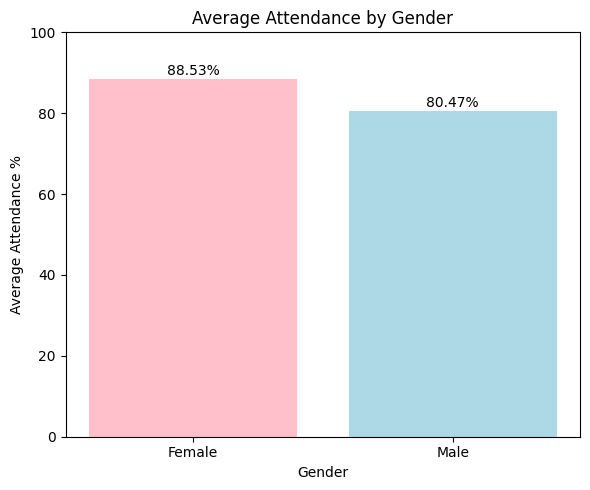

In [ ]:
query_top_students = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM student_performance
ORDER BY total_score DESC
LIMIT 8
"""
query_gender_attn = """
SELECT gender,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY gender
"""
run_query(query_top_students, "Top 8 Students by Total Score")
top_df = pd.read_sql_query(query_top_students, conn)
plt.figure(figsize=(10, 5))
plt.barh(top_df['name'], top_df['total_score'], color='mediumpurple')
plt.xlabel('Total Score')
plt.ylabel('Student Name')
plt.title('Top 8 Students by Total Score')
plt.gca().invert_yaxis()
for i, val in enumerate(top_df['total_score']):
    plt.text(val + 1, i, str(val), va='center')
plt.tight_layout()
plt.show()

run_query(query_gender_attn, "Average Attendance by Gender")

# Visualize Attendance by Gender
gender_df = pd.read_sql_query(query_gender_attn, conn)
plt.figure(figsize=(6, 5))
plt.bar(gender_df['gender'], gender_df['avg_attendance'], color=['pink', 'lightblue'])
plt.ylabel('Average Attendance %')
plt.xlabel('Gender')
plt.title('Average Attendance by Gender')
plt.ylim(0, 100)
for i, val in enumerate(gender_df['avg_attendance']):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center')
plt.tight_layout()
plt.show()


--- Top 8 Students by Total Score ---


,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356
5,Swati Kulkarni,354
6,Amit Bose,336
7,Suresh Rao,334


Rows returned: 8


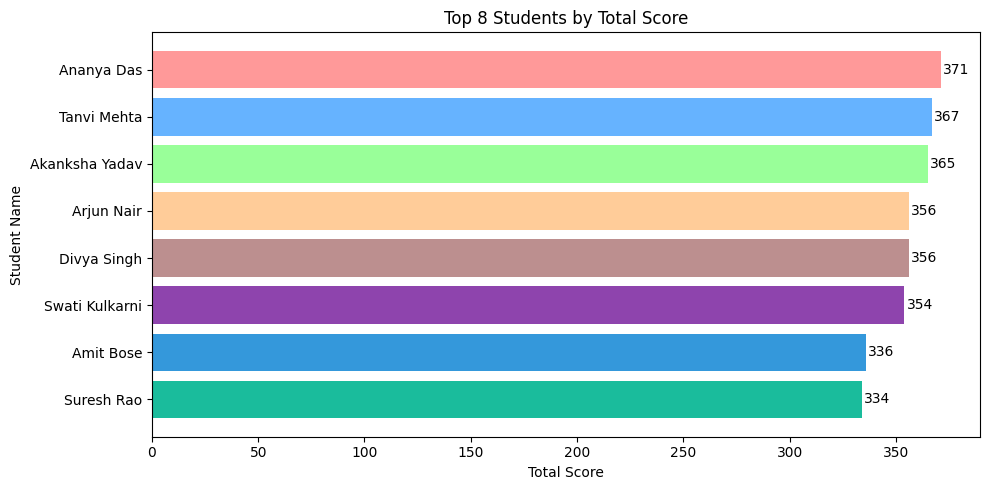


--- Average Attendance by Gender ---


,gender,avg_attendance
0,Female,88.533333
1,Male,80.466667


Rows returned: 2


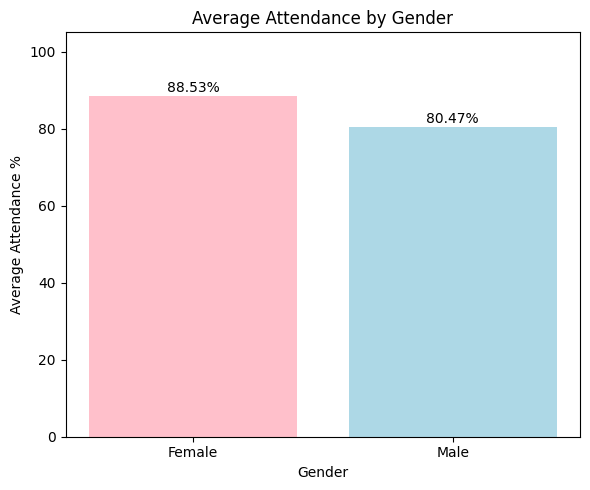

In [ ]:
top_student_colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#BC8F8F', '#8E44AD', '#3498DB', '#1ABC9C']
gender_colors = ['#FFC0CB', '#ADD8E6']

query_top_students = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM student_performance
ORDER BY total_score DESC
LIMIT 8
"""
run_query(query_top_students, "Top 8 Students by Total Score")


top_df = pd.read_sql_query(query_top_students, conn)
plt.figure(figsize=(10, 5))
plt.barh(top_df['name'], top_df['total_score'], color=top_student_colors)
plt.xlabel('Total Score')
plt.ylabel('Student Name')
plt.title('Top 8 Students by Total Score')
plt.gca().invert_yaxis()

for i, val in enumerate(top_df['total_score']):
    plt.text(val + 1, i, str(val), va='center')

plt.tight_layout()
plt.show()

query_gender_attn = """
SELECT gender,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY gender
"""
run_query(query_gender_attn, "Average Attendance by Gender")

gender_df = pd.read_sql_query(query_gender_attn, conn)
plt.figure(figsize=(6, 5))
plt.bar(gender_df['gender'], gender_df['avg_attendance'], color=gender_colors)
plt.ylabel('Average Attendance %')
plt.xlabel('Gender')
plt.title('Average Attendance by Gender')
plt.ylim(0, 105)

for i, val in enumerate(gender_df['avg_attendance']):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center')

plt.tight_layout()
plt.show()